In [67]:
import gdsfactory as gf
import numpy as np
import matplotlib.pyplot as plt
from gdsfactory.generic_tech import get_generic_pdk
from gdsfactory.typings import CrossSectionSpec, ComponentSpec
PDK = get_generic_pdk()
PDK.activate()

In [68]:
from a7_pcells_new_version import via_m1m2, via_m1m3, via_m2m3, via_htrm2
from a7_pcells_new_version import via_htrm3, via_slabm1, via_slabm2, via_slabm3
import functools
from functools import partial

In [69]:
# initializing the parameters
wvls = np.array([1.53977, 1.54056, 1.54135, 1.54214])
# radii = np.array([6.922029, 6.928063, 6.934103, 6.940147])
radii = np.array([9.89116406, 9.89993137, 9.90870169, 9.9174745])
gaps = np.array([0.1, 0.1, 0.1, 0.101])

vias1 = gf.components.via(size=(0.8,0.8), enclosure=1.5, layer="VIA1", pitch=2)
vias2 = gf.components.via(size=(0.8,0.8), enclosure=1.5, layer="VIA2", pitch=2)
viasc = gf.components.via(size=(0.8,0.8), enclosure=1.5, layer='VIAC', pitch=2)
via_m1m2 = partial(gf.components.via_stack,size=(11,11),layers=('M1','M2'),vias=(vias1,None))
via_m1m3 = partial(gf.components.via_stack,size=(11,11),layers=('M1','M2','M3'),vias=(vias1,vias2,None))
via_m2m3 = partial(gf.components.via_stack,size=(11,11),layers=('M2','M3'),vias=(vias2,None))
via_htrm2 = partial(gf.components.via_stack,size=(11,11),layers=('HEATER','M2'),vias=(vias1,None))
via_htrm3 = partial(gf.components.via_stack,size=(11,11),layers=('HEATER','M2','M3'),vias=(vias1,vias2,None))
via_slabm1 = partial(gf.components.via_stack,size=(11,11),layers=('SLAB90','M1'),vias=('viac',None))
via_slabm2 = partial(gf.components.via_stack,size=(11,11),layers=('SLAB90','M1','M2'),vias=('viac',vias1,None))
via_slabm3 = partial(gf.components.via_stack,size=(11,11),layers=('SLAB90','M1','M2','M3'),vias=('viac',vias1,'via2',None))

xs_sc = gf.get_cross_section("strip")
bend_sc = gf.partial(gf.c.bend_euler, cross_section=xs_sc)
straight_sc = straight = gf.partial(gf.c.straight, cross_section=xs_sc)
route_single_sc = gf.partial(gf.routing.route_single, cross_section=xs_sc, bend=bend_sc, straight=straight_sc)

In [70]:
def ring_double_pn_oriented_ports(
    radius=5,
    add_gap=0.2,
    drop_gap=0.2,
    port_orientations=None,
    **kwargs,
):
    c = gf.Component()

    r = c << gf.components.ring_double_pn(
        radius=radius,
        add_gap=add_gap,
        drop_gap=drop_gap,
        **kwargs,
    )

    if port_orientations is None:
        port_orientations={
            "htr_top_sig": 90,
            "htr_top_gnd": 90,
            "htr_bot_sig": 270,
            "htr_bot_gnd": 270,
            },

    for p in r.ports:
        if p.name in port_orientations:
            c.add_port(
                name=p.name,
                center=p.center,
                width=p.width,
                orientation=port_orientations[p.name],
                layer=p.layer,
                port_type=p.port_type,
            )
        else:
            c.add_port(
                name=p.name,
                port=p,
            )

    return c

Connecting ring 0 to ring1
Connecting ring 1 to ring2
Connecting ring 2 to ring3


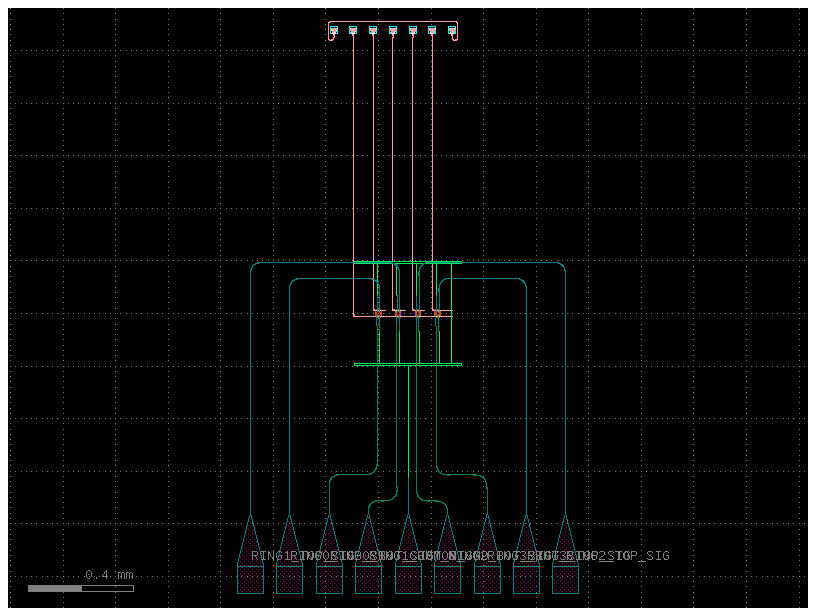

In [73]:
c = gf.Component()
ring_refs = []
ring_separation = 75
for i in range(4):
    radius = radii[i]
    gap = gaps[i]
    # ring = gf.components.ring_double_pn(add_gap=gap, drop_gap=gap, radius=radius)
    ring = ring_double_pn_oriented_ports(
        radius=radius,
        add_gap=gap,
        drop_gap=gap,
        port_orientations={
        "htr_top_sig": 90,
        "htr_top_gnd": 90,
        "htr_bot_sig": 270,
        "htr_bot_gnd": 270,
        },
    )
    ring_refs.append(c << ring)
    ring_refs[-1].movex(i*ring_separation)

for i in range(len(ring_refs)-1):
    p1 = ring_refs[i].ports["o2"]
    p2 = ring_refs[i+1].ports["o1"]

    dx = p2.center[0] - p1.center[0]
    dy = p2.center[1] - p1.center[1]

    print(f"Connecting ring {i} to ring{ i+1}")
    b = c << gf.components.straight(
        length=dx,
        cross_section="strip",
    )
    b.connect("o1", p1)


# Connecting the output bus to a coupling grater
for i, ref in enumerate(ring_refs):
    if i == 3:
        for pname in ["o2", "o3"]:
            p = ref.ports[pname]
            term = c << gf.components.taper(
                    length=50,
                    width1=p.width,
                    width2=0.05,
                    cross_section="strip",
                )
            term.connect("o1",p)
    
    p = ref.ports['o3']
    term = c << gf.components.taper(
                length=20,
                width1=p.width,
                width2=0.05,
                cross_section="strip",
            )
    term.connect("o1",p)

# padArr = c << linear_pad_array(n_pads=9)
padArr = c << gf.components.pad_array(columns=9, rows=1, port_orientation=90)
# padArr.rotate(90)
total_ring_width = ring_refs[-1].x - ring_refs[0].x
total_pad_width = padArr[-1].x - padArr[0].x
padArr.ymin = ring_refs[0].ymin - 1050
padArr.x = total_ring_width/2

gca = c << gf.components.grating_coupler_array(n=7, rotation=-90, pitch=75, with_loopback=True).copy()
gca.rotate(180)
gca.movey(1050)
gca.movex(ring_refs[1].x - 20)

coupler_ports = [gca.ports[f"o{i+1}"] for i in range(len(ring_refs))]
coupler_ports = coupler_ports[::-1]

for i in range(len(ring_refs)):
    gf.routing.route_single(
        c,
        ring_refs[i].ports["o4"],
        coupler_ports[i],
        cross_section="strip",
        radius=5
    )

# Routing output light to gca
gf.routing.route_single(
    c,
    gca.ports["o5"],
    ring_refs[0].ports["o1"],
    cross_section="strip",
    radius=5
)
xs_m1 = gf.CrossSection(sections=[gf.Section(width=10,layer='M1',port_names=('e1','e2'),port_types=('electrical','electrical'))])
xs_m2 = gf.CrossSection(sections=[gf.Section(width=10,layer='M2',port_names=('e1','e2'),port_types=('electrical','electrical'))])
xs_m3 = gf.CrossSection(sections=[gf.Section(width=10,layer='M3',port_names=('e1','e2'),port_types=('electrical','electrical'))])

# =================================================
# Electrical signal routing
# Top heater signals: M3
# Bottom heater signals: M2
# Route width = heater port width
# =================================================

def xs_metal(layer, width):
    return gf.CrossSection(
        sections=[
            gf.Section(
                width=width,
                layer=layer,
                port_names=("e1", "e2"),
                port_types=("electrical", "electrical"),
            )
        ]
    )


heater_w = ring_refs[0].ports["htr_top_sig"].width

xs_m2_heater = xs_metal("M2", heater_w)
xs_m3_heater = xs_metal("M3", heater_w)

via_size = (heater_w, heater_w)
via_cut_size = (0.2, 0.2)


# =================================================
# Pad taper: pad width -> heater width on M3
# =================================================

def taper_pad_to_width(
    c,
    pad_port,
    final_width=heater_w,
    taper_len=200,
    layer="M3",
):
    taper = c << gf.components.taper(
        length=taper_len,
        width1=pad_port.width,
        width2=final_width,
        layer=layer,
        port_names=("e1", "e2"),
        port_types=("electrical", "electrical"),
    )
    taper.connect("e1", pad_port)

    return taper.ports["e2"]


# =================================================
# M3 <-> M2 via stack with heater-width ports
# =================================================

def via_m3_m2_stack(size=via_size, via_size=via_cut_size):
    v = gf.Component()
    w, h = size

    _m2 = v << gf.components.rectangle(
        size=size,
        layer="M2",
        centered=True,
    )

    _m3 = v << gf.components.rectangle(
        size=size,
        layer="M3",
        centered=True,
    )

    via = v << gf.components.via(
        size=via_size,
        layer="VIA2",
    )
    via.center = (0, 0)

    # M3 ports
    v.add_port("m3_w", center=(-w / 2, 0), width=h, orientation=180, layer="M3", port_type="electrical")
    v.add_port("m3_e", center=( w / 2, 0), width=h, orientation=0,   layer="M3", port_type="electrical")
    v.add_port("m3_s", center=(0, -h / 2), width=w, orientation=270, layer="M3", port_type="electrical")
    v.add_port("m3_n", center=(0,  h / 2), width=w, orientation=90,  layer="M3", port_type="electrical")

    # M2 ports
    v.add_port("m2_w", center=(-w / 2, 0), width=h, orientation=180, layer="M2", port_type="electrical")
    v.add_port("m2_e", center=( w / 2, 0), width=h, orientation=0,   layer="M2", port_type="electrical")
    v.add_port("m2_s", center=(0, -h / 2), width=w, orientation=270, layer="M2", port_type="electrical")
    v.add_port("m2_n", center=(0,  h / 2), width=w, orientation=90,  layer="M2", port_type="electrical")

    return v


# =================================================
# Pad-side M3 launch to M2
# Used for bottom heater signals
# =================================================

def pad_to_m2_port(
    c,
    pad_port,
    taper_len=200,
):
    pad_m3 = taper_pad_to_width(
        c,
        pad_port,
        final_width=heater_w,
        taper_len=taper_len,
        layer="M3",
    )

    v32 = c << via_m3_m2_stack(
        size=via_size,
        via_size=via_cut_size,
    )
    v32.connect("m3_s", pad_m3)

    return v32.ports["m2_n"]


# =================================================
# Ring-side M3 heater port to M2
# Used for bottom heater signals
# =================================================

def heater_to_m2_port(
    c,
    heater_port,
    stub_len=40,
):
    stub = c << gf.components.straight(
        length=stub_len,
        cross_section=xs_m3_heater,
    )
    stub.connect("e1", heater_port)

    v32 = c << via_m3_m2_stack(
        size=via_size,
        via_size=via_cut_size,
    )
    v32.connect("m3_w", stub.ports["e2"])

    return v32.ports["m2_e"]


# =================================================
# Top heater signal routing on M3
#
# e11 -> ring_refs[1].htr_top_sig
# e12 -> ring_refs[0].htr_top_sig
# e18 -> ring_refs[3].htr_top_sig
# e19 -> ring_refs[2].htr_top_sig
# =================================================

pad_e11_m3 = taper_pad_to_width(
    c,
    padArr.ports["e11"],
    final_width=heater_w,
    taper_len=200,
    layer="M3",
)

pad_e12_m3 = taper_pad_to_width(
    c,
    padArr.ports["e12"],
    final_width=heater_w,
    taper_len=200,
    layer="M3",
)

pad_e18_m3 = taper_pad_to_width(
    c,
    padArr.ports["e18"],
    final_width=heater_w,
    taper_len=200,
    layer="M3",
)

pad_e19_m3 = taper_pad_to_width(
    c,
    padArr.ports["e19"],
    final_width=heater_w,
    taper_len=200,
    layer="M3",
)

m3_temp = c << gf.components.straight(
    length=100,
    cross_section=xs_m3_heater
)
m3_temp.connect("e2", pad_e11_m3)
# x0, y0 = pad_e11_m3.center
# gf.routing.route_single(
#     c,
#     m3_temp.ports["e1"],
#     ring_refs[1].ports["htr_top_sig"],
#     cross_section=xs_m3_heater,
#     radius=50,
# )

# -------------------------------------------------
# Offset M3 top-signal routes to prevent overlap
# First pad route and last pad route go higher
# -------------------------------------------------

top_route_y_low = max(ref.ymax for ref in ring_refs) + 120
top_route_y_high = max(ref.ymax for ref in ring_refs) + 180

# First pad: e11 -> second ring htr_top_sig
# Extend higher than e12 route
p_start = m3_temp.ports["e1"]
p_end = ring_refs[1].ports["htr_top_sig"]

gf.routing.route_single(
    c,
    p_start,
    p_end,
    cross_section=xs_m3_heater,
    radius=50,
    waypoints=[
        (p_start.center[0], top_route_y_high),
        (p_end.center[0], top_route_y_high),
    ],
)

# Second pad: e12 -> first ring htr_top_sig
p_start = pad_e12_m3
p_end = ring_refs[0].ports["htr_top_sig"]

gf.routing.route_single(
    c,
    p_start,
    p_end,
    cross_section=xs_m3_heater,
    radius=50,
    waypoints=[
        (p_start.center[0], top_route_y_low),
        (p_end.center[0], top_route_y_low),
    ],
)

# Second-to-last pad: e18 -> last ring htr_top_sig
p_start = pad_e18_m3
p_end = ring_refs[3].ports["htr_top_sig"]

gf.routing.route_single(
    c,
    p_start,
    p_end,
    cross_section=xs_m3_heater,
    radius=50,
    waypoints=[
        (p_start.center[0], top_route_y_low),
        (p_end.center[0], top_route_y_low),
    ],
)

# Last pad: e19 -> third ring htr_top_sig
# Extend higher than e18 route
p_start = pad_e19_m3
p_end = ring_refs[2].ports["htr_top_sig"]

gf.routing.route_single(
    c,
    p_start,
    p_end,
    cross_section=xs_m3_heater,
    radius=50,
    waypoints=[
        (p_start.center[0], top_route_y_high),
        (p_end.center[0], top_route_y_high),
    ],
)


# =================================================
# Bottom heater signal routing on M2
#
# e13 -> ring_refs[1].htr_bot_sig
# e14 -> ring_refs[0].htr_bot_sig
# e16 -> ring_refs[3].htr_bot_sig
# e17 -> ring_refs[2].htr_bot_sig
# =================================================

pad_e13_m2 = pad_to_m2_port(
    c,
    padArr.ports["e13"],
    taper_len=200,
)

pad_e14_m2 = pad_to_m2_port(
    c,
    padArr.ports["e14"],
    taper_len=200,
)

pad_e16_m2 = pad_to_m2_port(
    c,
    padArr.ports["e16"],
    taper_len=200,
)

pad_e17_m2 = pad_to_m2_port(
    c,
    padArr.ports["e17"],
    taper_len=200,
)


r1_bot_sig_m2 = heater_to_m2_port(
    c,
    ring_refs[1].ports["htr_bot_sig"],
    stub_len=40,
)

r0_bot_sig_m2 = heater_to_m2_port(
    c,
    ring_refs[0].ports["htr_bot_sig"],
    stub_len=40,
)

r3_bot_sig_m2 = heater_to_m2_port(
    c,
    ring_refs[3].ports["htr_bot_sig"],
    stub_len=40,
)

r2_bot_sig_m2 = heater_to_m2_port(
    c,
    ring_refs[2].ports["htr_bot_sig"],
    stub_len=40,
)

temp_straight = c << gf.components.straight(
    length=100,
    cross_section=xs_m2_heater
)
temp_straight.connect("e1", pad_e13_m2)
gf.routing.route_single(
    c,
    temp_straight["e2"],
    r0_bot_sig_m2,
    cross_section=xs_m2_heater,
    radius=50,
)

gf.routing.route_single(
    c,
    pad_e14_m2,
    r1_bot_sig_m2,
    cross_section=xs_m2_heater,
    radius=50,
)

gf.routing.route_single(
    c,
    pad_e16_m2,
    r2_bot_sig_m2,
    cross_section=xs_m2_heater,
    radius=50,
    waypoints=[]
)


temp = c << gf.components.straight(
    length=100,
    cross_section=xs_m2_heater
)

temp.connect("e1", pad_e17_m2)
gf.routing.route_single(
    c,
    temp.ports["e2"],
    r3_bot_sig_m2,
    cross_section=xs_m2_heater,
    radius=50,
)

# =================================================
# Common GND routing
# - Top GND ports route to an upper M1 bus
# - Bottom GND ports route to a lower M1 bus
# - Upper and lower buses are shorted by one vertical M1 strap
# - Pad e15 tapers away, drops to M1, then routes to lower bus
# =================================================

def xs_metal(layer, width):
    return gf.CrossSection(
        sections=[
            gf.Section(
                width=width,
                layer=layer,
                port_names=("e1", "e2"),
                port_types=("electrical", "electrical"),
            )
        ]
    )


gnd_w = ring_refs[0].ports["htr_top_gnd"].width

xs_m1_gnd = xs_metal("M1", gnd_w)
xs_m2_gnd = xs_metal("M2", gnd_w)
xs_m3_gnd = xs_metal("M3", gnd_w)

via_size = (gnd_w, gnd_w)
via_cut_size = (0.2, 0.2)


# -------------------------------------------------
# M3 <-> M2 via stack
# -------------------------------------------------

def via_m3_m2_stack(size=via_size, via_cut_size=via_cut_size):
    v = gf.Component()
    w, h = size

    _m2 = v << gf.components.rectangle(
        size=size,
        layer="M2",
        centered=True,
    )

    _m3 = v << gf.components.rectangle(
        size=size,
        layer="M3",
        centered=True,
    )

    via = v << gf.components.via(
        size=via_cut_size,
        layer="VIA2",
    )
    via.center = (0, 0)

    v.add_port("m3_w", center=(-w / 2, 0), width=h, orientation=180, layer="M3", port_type="electrical")
    v.add_port("m3_e", center=( w / 2, 0), width=h, orientation=0,   layer="M3", port_type="electrical")
    v.add_port("m3_s", center=(0, -h / 2), width=w, orientation=270, layer="M3", port_type="electrical")
    v.add_port("m3_n", center=(0,  h / 2), width=w, orientation=90,  layer="M3", port_type="electrical")

    v.add_port("m2_w", center=(-w / 2, 0), width=h, orientation=180, layer="M2", port_type="electrical")
    v.add_port("m2_e", center=( w / 2, 0), width=h, orientation=0,   layer="M2", port_type="electrical")
    v.add_port("m2_s", center=(0, -h / 2), width=w, orientation=270, layer="M2", port_type="electrical")
    v.add_port("m2_n", center=(0,  h / 2), width=w, orientation=90,  layer="M2", port_type="electrical")

    return v


# -------------------------------------------------
# M2 <-> M1 via stack
# -------------------------------------------------

def via_m2_m1_stack(size=via_size, via_cut_size=via_cut_size):
    v = gf.Component()
    w, h = size

    _m1 = v << gf.components.rectangle(
        size=size,
        layer="M1",
        centered=True,
    )

    _m2 = v << gf.components.rectangle(
        size=size,
        layer="M2",
        centered=True,
    )

    via = v << gf.components.via(
        size=via_cut_size,
        layer="VIA1",
    )
    via.center = (0, 0)

    v.add_port("m2_w", center=(-w / 2, 0), width=h, orientation=180, layer="M2", port_type="electrical")
    v.add_port("m2_e", center=( w / 2, 0), width=h, orientation=0,   layer="M2", port_type="electrical")
    v.add_port("m2_s", center=(0, -h / 2), width=w, orientation=270, layer="M2", port_type="electrical")
    v.add_port("m2_n", center=(0,  h / 2), width=w, orientation=90,  layer="M2", port_type="electrical")

    v.add_port("m1_w", center=(-w / 2, 0), width=h, orientation=180, layer="M1", port_type="electrical")
    v.add_port("m1_e", center=( w / 2, 0), width=h, orientation=0,   layer="M1", port_type="electrical")
    v.add_port("m1_s", center=(0, -h / 2), width=w, orientation=270, layer="M1", port_type="electrical")
    v.add_port("m1_n", center=(0,  h / 2), width=w, orientation=90,  layer="M1", port_type="electrical")

    return v


# -------------------------------------------------
# Pad e15: taper away from pad, then drop to M1
# -------------------------------------------------

def pad_to_m1_port(
    c,
    pad_port,
    taper_len=200,
    m3_escape_len=120,
    m2_escape_len=20,
):
    pad_taper = c << gf.components.taper(
        length=taper_len,
        width1=pad_port.width,
        width2=gnd_w,
        layer="M3",
        port_names=("e1", "e2"),
        port_types=("electrical", "electrical"),
    )
    pad_taper.connect("e1", pad_port)

    m3_escape = c << gf.components.straight(
        length=m3_escape_len,
        cross_section=xs_m3_gnd,
    )
    m3_escape.connect("e1", pad_taper.ports["e2"])

    v32 = c << via_m3_m2_stack(
        size=via_size,
        via_cut_size=via_cut_size,
    )
    v32.connect("m3_s", m3_escape.ports["e2"])

    m2_escape = c << gf.components.straight(
        length=m2_escape_len,
        cross_section=xs_m2_gnd,
    )
    m2_escape.connect("e1", v32.ports["m2_n"])

    v21 = c << via_m2_m1_stack(
        size=via_size,
        via_cut_size=via_cut_size,
    )
    v21.connect("m2_s", m2_escape.ports["e2"])

    return v21.ports["m1_n"]


# -------------------------------------------------
# GND heater port: local M3, drop to M1
# -------------------------------------------------

def gnd_heater_to_m1_port(
    c,
    gnd_port,
    m3_stub_len=40,
    m2_stub_len=20,
):
    m3_stub = c << gf.components.straight(
        length=m3_stub_len,
        cross_section=xs_m3_gnd,
    )
    m3_stub.connect("e1", gnd_port)

    v32 = c << via_m3_m2_stack(
        size=via_size,
        via_cut_size=via_cut_size,
    )
    v32.connect("m3_w", m3_stub.ports["e2"])

    m2_stub = c << gf.components.straight(
        length=m2_stub_len,
        cross_section=xs_m2_gnd,
    )
    m2_stub.connect("e1", v32.ports["m2_e"])

    v21 = c << via_m2_m1_stack(
        size=via_size,
        via_cut_size=via_cut_size,
    )
    v21.connect("m2_w", m2_stub.ports["e2"])

    return v21.ports["m1_e"]


# -------------------------------------------------
# Build upper and lower M1 GND buses
# -------------------------------------------------

gnd_bus_y_offset = 180
gnd_bus_margin = 80
gnd_bus_width = 5

ring_xmin = min(ref.xmin for ref in ring_refs)
ring_xmax = max(ref.xmax for ref in ring_refs)
ring_ymin = min(ref.ymin for ref in ring_refs)
ring_ymax = max(ref.ymax for ref in ring_refs)

gnd_bus_xmin = ring_xmin - gnd_bus_margin
gnd_bus_xmax = ring_xmax + gnd_bus_margin
gnd_bus_length = gnd_bus_xmax - gnd_bus_xmin

top_gnd_bus_y = ring_ymax + gnd_bus_y_offset
bot_gnd_bus_y = ring_ymin - gnd_bus_y_offset

top_gnd_bus = c << gf.components.rectangle(
    size=(gnd_bus_length, gnd_bus_width),
    layer="M1",
    centered=False,
)
top_gnd_bus.xmin = gnd_bus_xmin
top_gnd_bus.ymin = top_gnd_bus_y - gnd_bus_width / 2

bot_gnd_bus = c << gf.components.rectangle(
    size=(gnd_bus_length, gnd_bus_width),
    layer="M1",
    centered=False,
)
bot_gnd_bus.xmin = gnd_bus_xmin
bot_gnd_bus.ymin = bot_gnd_bus_y - gnd_bus_width / 2


# -------------------------------------------------
# Drop top GND ports to M1 and route to upper bus
# -------------------------------------------------

top_gnd_m1_ports = []

for i, ref in enumerate(ring_refs):
    top_gnd_m1_ports.append(
        gnd_heater_to_m1_port(
            c,
            ref.ports["htr_top_gnd"],
            m3_stub_len=40,
            m2_stub_len=20,
        )
    )

for k, p in enumerate(top_gnd_m1_ports):
    bus_port_name = f"top_gnd_bus_tap_{k}"

    c.add_port(
        name=bus_port_name,
        center=(p.center[0], top_gnd_bus_y - gnd_bus_width / 2),
        width=gnd_w,
        orientation=270,
        layer="M1",
        port_type="electrical",
    )

    gf.routing.route_single(
        c,
        p,
        c.ports[bus_port_name],
        cross_section=xs_m1_gnd,
        radius=50,
    )


# -------------------------------------------------
# Drop bottom GND ports to M1 and route to lower bus
# -------------------------------------------------

bot_gnd_m1_ports = []

for i, ref in enumerate(ring_refs):
    bot_gnd_m1_ports.append(
        gnd_heater_to_m1_port(
            c,
            ref.ports["htr_bot_gnd"],
            m3_stub_len=40,
            m2_stub_len=20,
        )
    )

for k, p in enumerate(bot_gnd_m1_ports):
    bus_port_name = f"bot_gnd_bus_tap_{k}"

    c.add_port(
        name=bus_port_name,
        center=(p.center[0], bot_gnd_bus_y + gnd_bus_width / 2),
        width=gnd_w,
        orientation=90,
        layer="M1",
        port_type="electrical",
    )

    gf.routing.route_single(
        c,
        p,
        c.ports[bus_port_name],
        cross_section=xs_m1_gnd,
        radius=50,
    )


# -------------------------------------------------
# Tie upper and lower GND buses together with one M1 strap
# Place strap to the right of the rings
# -------------------------------------------------

strap_x = ring_xmax + gnd_bus_margin / 2

c.add_port(
    name="top_gnd_bus_strap",
    center=(strap_x, top_gnd_bus_y - gnd_bus_width / 2),
    width=gnd_w,
    orientation=270,
    layer="M1",
    port_type="electrical",
)

c.add_port(
    name="bot_gnd_bus_strap",
    center=(strap_x, bot_gnd_bus_y + gnd_bus_width / 2),
    width=gnd_w,
    orientation=90,
    layer="M1",
    port_type="electrical",
)

gf.routing.route_single(
    c,
    c.ports["top_gnd_bus_strap"],
    c.ports["bot_gnd_bus_strap"],
    cross_section=xs_m1_gnd,
    radius=50,
)


# -------------------------------------------------
# Route pad e15 to lower GND bus
# -------------------------------------------------

pad_e15_m1 = pad_to_m1_port(
    c,
    padArr.ports["e15"],
    taper_len=200,
    m3_escape_len=120,
    m2_escape_len=20,
)

c.add_port(
    name="pad_e15_to_bot_gnd_bus",
    center=(pad_e15_m1.center[0], bot_gnd_bus_y - gnd_bus_width / 2),
    width=gnd_w,
    orientation=270,
    layer="M1",
    port_type="electrical",
)

gf.routing.route_single(
    c,
    pad_e15_m1,
    c.ports["pad_e15_to_bot_gnd_bus"],
    cross_section=xs_m1_gnd,
    radius=50,
)

pad_labels = {
    "e11": "RING1_TOP_SIG",
    "e12": "RING0_TOP_SIG",
    "e13": "RING0_BOT_SIG",
    "e14": "RING1_BOT_SIG",
    "e15": "COMMON_GND",
    "e16": "RING2_BOT_SIG",
    "e17": "RING3_BOT_SIG",
    "e18": "RING3_TOP_SIG",
    "e19": "RING2_TOP_SIG",
}

for port_name, label in pad_labels.items():
    c.add_label(
        text=label,
        position=padArr.ports[port_name].center,
        layer=(66, 0),
    )
c.write_gds("tx.gds")
c.plot()